Airline Route Profitability Analysis

Project Objective: Analysis of the profitability of different flight routes based on revenue, cost, and operational data.

Business Questions

1.  Which route achieves the highest profit margin?
2. Which route is operating at a loss?
3. Which distance category is the most profitable?
4. Which aircraft types are the most efficient?
5. Which cost category has the strongest impact on profit?

Goal: Provide actionable recommendations for route and cost optimization.

In [38]:
#LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

sns.set_style("whitegrid")
plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

In [19]:
#DATEN LADEN
df = pd.read_csv("airline_route_profitability.csv")

df.head()

,Flight_Number,Flight_Date,Origin,Destination,Route,Aircraft_Type,Aircraft_Capacity,Passengers,Load_Factor,Flight_Hours,Season,Route_Category,Demand_Level,Ticket_Revenue,Ancillary_Revenue,Total_Revenue,Fuel_Cost,Maintenance_Cost,Crew_Cost,Depreciation_Cost,Insurance_Cost,Airport_Fees,Catering_Cost,Handling_Cost,Navigation_Fees,Sales_Distribution_Cost,Passenger_Service_Cost,Overhead_Cost,Marketing_Cost,IT_Systems_Cost,Total_Cost,Profit,Profit_Margin
0,EK8960,2024-12-20,DXB,ORD,DXB-ORD,Boeing 777-300ER,396,308,0.7791,14.5,Peak,Long Haul,Medium,410785.49,53431.94,464217.43,131033.88,50750.0,21750.0,65250.0,11600.0,4262.30,5185.86,4460.11,10636.90,78193.60,5100.09,88545.73,25883.92,3769.37,506421.77,-42204.34,-9.09
1,EK3960,2024-05-13,DXB,HYD,DXB-HYD,Boeing 787-9,296,234,0.7910,4.2,Normal,Medium Haul,Medium,145890.17,17695.27,163585.44,21338.76,9240.0,5040.0,13440.0,2520.0,2016.63,5851.01,5425.84,3027.25,21586.21,6022.20,17057.61,8820.56,1937.81,123323.88,40261.57,24.61
2,EK7529,2024-10-12,DXB,CDG,DXB-CDG,Boeing 787-9,296,251,0.8502,7.5,Shoulder,Long Haul,High,602841.03,78724.16,681565.19,41011.77,16500.0,9000.0,24000.0,4500.0,10764.79,4134.08,3761.85,3431.70,100188.97,6514.22,31347.38,23695.34,3415.99,282266.09,399299.10,58.59
3,EK4543,2024-06-25,DXB,DEL,DXB-DEL,Boeing 787-9,296,229,0.7748,3.5,Low,Medium Haul,High,126485.16,17543.26,144028.42,17333.86,7700.0,4200.0,11200.0,2100.0,6508.04,6508.73,4440.93,2079.79,22686.82,4791.21,15328.62,6795.49,2245.61,113919.11,30109.31,20.91
4,EK3114,2024-04-20,DXB,RUH,DXB-RUH,Airbus A320,180,142,0.7901,2.2,Shoulder,Short Haul,Medium,32651.15,3871.66,36522.81,5576.80,2530.0,1716.0,3740.0,616.0,4718.58,3360.52,3414.18,1662.49,5133.62,3094.65,8252.23,1492.53,1273.27,46580.86,-10058.06,-27.54


In [20]:
#DATA UNDERSTANDING
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (7974, 33)

Missing Values:
 Flight_Number                0
Flight_Date                  0
Origin                       0
Destination                  0
Route                        0
Aircraft_Type                0
Aircraft_Capacity            0
Passengers                   0
Load_Factor                  0
Flight_Hours                 0
Season                       0
Route_Category               0
Demand_Level                 0
Ticket_Revenue               0
Ancillary_Revenue          271
Total_Revenue                0
Fuel_Cost                    0
Maintenance_Cost             0
Crew_Cost                    0
Depreciation_Cost            0
Insurance_Cost               0
Airport_Fees                 0
Catering_Cost              265
Handling_Cost              256
Navigation_Fees              0
Sales_Distribution_Cost      0
Passenger_Service_Cost       0
Overhead_Cost                0
Marketing_Cost               0
IT_Systems_Cost              0
Total_Cost                   0
Pro

In [21]:
#DATA CLEANING
df["Flight_Date"] = pd.to_datetime(df["Flight_Date"])

numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

df.describe()

,Flight_Date,Aircraft_Capacity,Passengers,Load_Factor,Flight_Hours,Ticket_Revenue,Ancillary_Revenue,Total_Revenue,Fuel_Cost,Maintenance_Cost,Crew_Cost,Depreciation_Cost,Insurance_Cost,Airport_Fees,Catering_Cost,Handling_Cost,Navigation_Fees,Sales_Distribution_Cost,Passenger_Service_Cost,Overhead_Cost,Marketing_Cost,IT_Systems_Cost,Total_Cost,Profit,Profit_Margin
count,7974,7974.000000,7974.000000,7974.000000,7974.000000,7.974000e+03,7703.000000,7.974000e+03,7974.000000,7974.000000,7974.000000,7974.000000,7974.000000,7974.000000,7709.000000,7718.000000,7974.000000,7974.000000,7974.000000,7974.000000,7974.000000,7974.000000,7974.000000,7974.000000,7974.000000
mean,2024-07-01 05:23:25.869074432,317.800602,254.819162,0.801570,6.327314,2.643839e+05,33073.717197,2.974362e+05,46296.405878,18973.224856,8905.116880,25258.814898,4504.945699,5054.911403,5998.747912,3988.998616,3785.569431,44659.242364,5721.982070,35742.265706,13448.184059,2930.738501,225266.563756,72169.633934,6.190222
min,2024-01-01 00:00:00,180.000000,104.000000,0.576600,1.200000,1.481234e+04,1616.620000,1.665002e+04,2592.620000,1380.000000,936.000000,2040.000000,336.000000,2000.790000,1398.400000,2000.040000,483.570000,2143.110000,1750.110000,3750.190000,608.620000,923.260000,28019.380000,-250914.850000,-236.270000
25%,2024-04-01 00:00:00,296.000000,180.250000,0.736825,3.200000,5.642951e+04,7234.405000,6.350239e+04,16137.575000,7040.000000,3840.000000,10240.000000,1920.000000,3197.342500,3962.540000,2991.377500,1602.465000,9690.980000,4002.195000,13955.147500,2942.397500,2063.495000,83612.367500,-9052.485000,-10.747500
50%,2024-07-01 00:00:00,325.000000,246.000000,0.801500,4.500000,1.826204e+05,22842.850000,2.048126e+05,28344.950000,11200.000000,5850.000000,15750.000000,2925.000000,4335.755000,5504.910000,3971.835000,2879.290000,31167.845000,5386.070000,24366.945000,9235.870000,2772.270000,154808.355000,21326.055000,15.215000
75%,2024-10-01 00:00:00,396.000000,302.000000,0.873100,7.500000,4.126969e+05,51234.975000,4.638002e+05,74832.960000,30800.000000,13000.000000,39000.000000,6800.000000,6562.855000,7494.680000,4974.315000,5084.895000,68973.712500,7018.972500,54205.342500,20226.527500,3576.795000,355441.002500,116046.090000,33.280000
max,2024-12-31 00:00:00,517.000000,491.000000,0.950000,16.500000,1.303645e+06,192921.910000,1.496567e+06,191047.780000,72500.000000,29000.000000,87000.000000,14500.000000,11998.990000,17079.700000,5999.980000,13166.360000,222595.180000,14601.280000,144736.040000,78018.070000,7354.160000,835108.700000,972133.760000,64.960000
std,NaN,98.768543,88.141968,0.087755,4.555668,2.371022e+05,30167.518230,2.668329e+05,43123.036900,17677.194300,7414.772748,22152.943693,3872.411136,2492.832311,2729.957117,1146.741218,2861.881472,40575.117395,2295.208112,29368.802114,12633.987523,1154.464363,174526.327680,138692.750890,39.040588


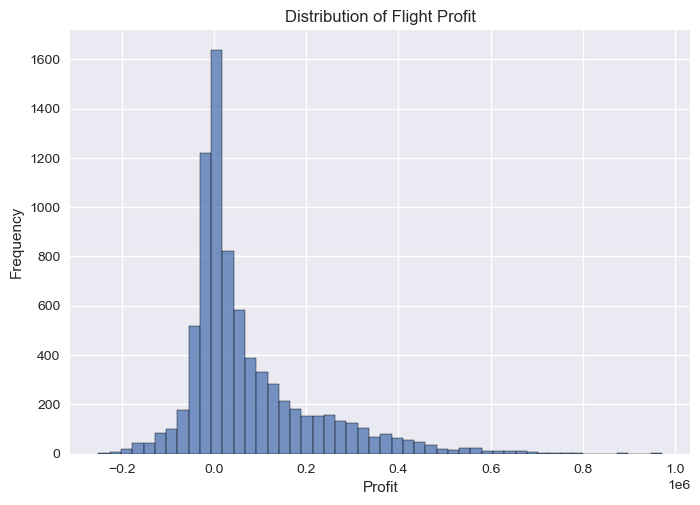

In [22]:
#PROFIT DISTRIBUTION
plt.figure()
sns.histplot(df["Profit"], bins=50)
plt.title("Distribution of Flight Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

In [23]:
#ROUTENRENTABILITÄT
route_analysis = df.groupby("Route").agg({
    "Profit": "mean",
    "Profit_Margin": "mean",
    "Total_Revenue": "mean",
    "Total_Cost": "mean"
}).reset_index()

route_analysis = route_analysis.sort_values("Profit_Margin", ascending=False)

route_analysis.head()

,Route,Profit,Profit_Margin,Total_Revenue,Total_Cost
10,DXB-FRA,306127.700123,46.080000,630437.427169,324309.726954
28,DXB-SIN,284358.997812,42.072750,637295.123187,352936.125125
6,DXB-CDG,279190.668328,41.265944,631535.230495,352344.561703
2,DXB-BKK,191339.381038,39.905236,447922.079858,256582.698491
11,DXB-HKG,269674.333614,38.667681,657368.870271,387694.536325


In [24]:
#BEST & WORST ROUTE
best_route = route_analysis.iloc[0]
worst_route = route_analysis.iloc[-1]

print("Best Route:")
print(best_route)

print("\n Worst Route:")
print(worst_route)

Best Route:
Route                  DXB-FRA
Profit           306127.700123
Profit_Margin            46.08
Total_Revenue    630437.427169
Total_Cost       324309.726954
Name: 10, dtype: object

 Worst Route:
Route                 DXB-CAI
Profit          -40747.362239
Profit_Margin      -83.958159
Total_Revenue    58101.130796
Total_Cost       98848.492736
Name: 5, dtype: object


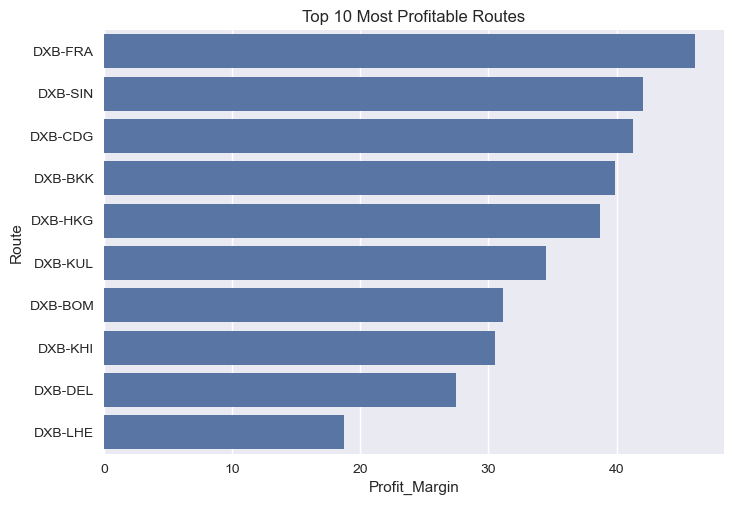

In [25]:
#TOP 10 ROUTE VISUELL
plt.figure()
sns.barplot(data=route_analysis.head(10),
            x="Profit_Margin",
            y="Route")
plt.title("Top 10 Most Profitable Routes")
plt.show()

In [26]:
#Loss-making routes
loss_routes = route_analysis[route_analysis["Profit_Margin"] < 0]
loss_routes

,Route,Profit,Profit_Margin,Total_Revenue,Total_Cost
9,DXB-DOH,1911.220059,-0.979734,43756.937308,41845.717485
25,DXB-ORD,18075.326729,-1.622664,446840.052103,428764.725280
18,DXB-KWI,-1847.598944,-10.633431,44501.207537,46348.806745
27,DXB-SFO,-28543.819571,-12.707810,447955.603095,476499.423286
21,DXB-LHR,-19475.519622,-13.442500,244594.719738,264070.238924
19,DXB-LAX,-38375.567039,-15.592718,424358.866553,462734.432961
26,DXB-RUH,-11163.425880,-41.197731,33698.506111,44861.932593
14,DXB-JED,-18911.869610,-68.188488,32793.683902,51705.552390
0,DXB-AMM,-36132.312100,-76.294155,56841.217397,92973.529772
5,DXB-CAI,-40747.362239,-83.958159,58101.130796,98848.492736


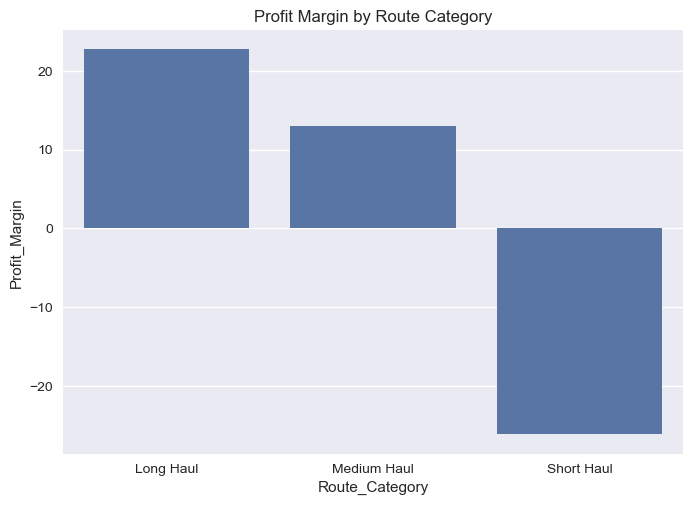

,Route_Category,Profit_Margin
0,Long Haul,22.710050
1,Medium Haul,12.959348
2,Short Haul,-26.117973


In [27]:
#Profit by route type”
category_analysis = df.groupby("Route_Category")["Profit_Margin"].mean().reset_index()

plt.figure()
sns.barplot(data=category_analysis,
            x="Route_Category",
            y="Profit_Margin")
plt.title("Profit Margin by Route Category")
plt.show()

category_analysis

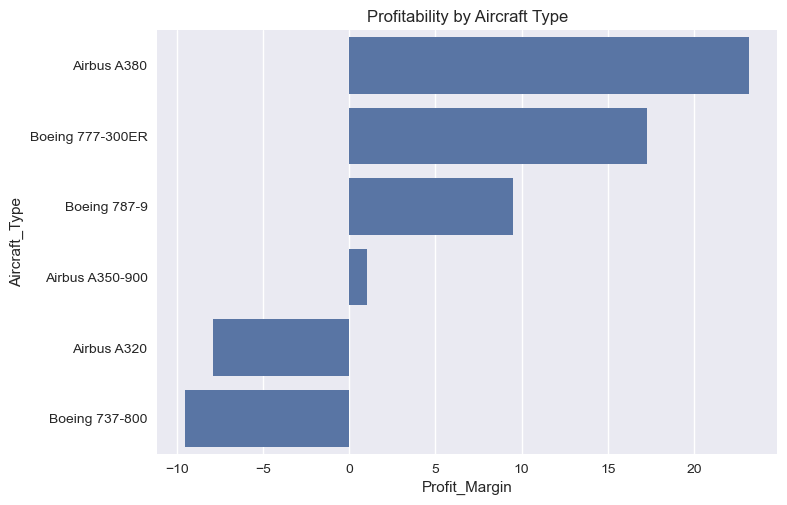

,Aircraft_Type,Profit_Margin
2,Airbus A380,23.181375
4,Boeing 777-300ER,17.259136
5,Boeing 787-9,9.478240
1,Airbus A350-900,1.040706
0,Airbus A320,-7.872992
3,Boeing 737-800,-9.502458


In [28]:
#Profit by aircraft type
aircraft_analysis = df.groupby("Aircraft_Type")["Profit_Margin"].mean().reset_index()
aircraft_analysis = aircraft_analysis.sort_values("Profit_Margin", ascending=False)

plt.figure()
sns.barplot(data=aircraft_analysis,
            x="Profit_Margin",
            y="Aircraft_Type")
plt.title("Profitability by Aircraft Type")
plt.show()

aircraft_analysis

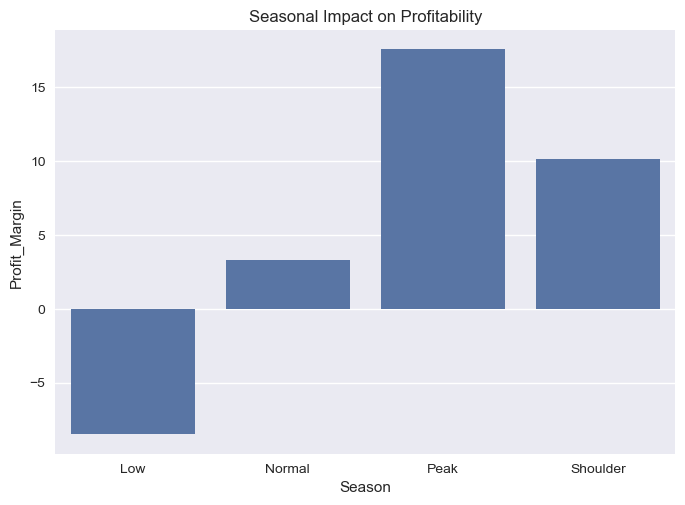

,Season,Profit_Margin
0,Low,-8.500365
1,Normal,3.330891
2,Peak,17.546783
3,Shoulder,10.139067


In [29]:
#Seasonal analysis
season_analysis = df.groupby("Season")["Profit_Margin"].mean().reset_index()

plt.figure()
sns.barplot(data=season_analysis,
            x="Season",
            y="Profit_Margin")
plt.title("Seasonal Impact on Profitability")
plt.show()

season_analysis

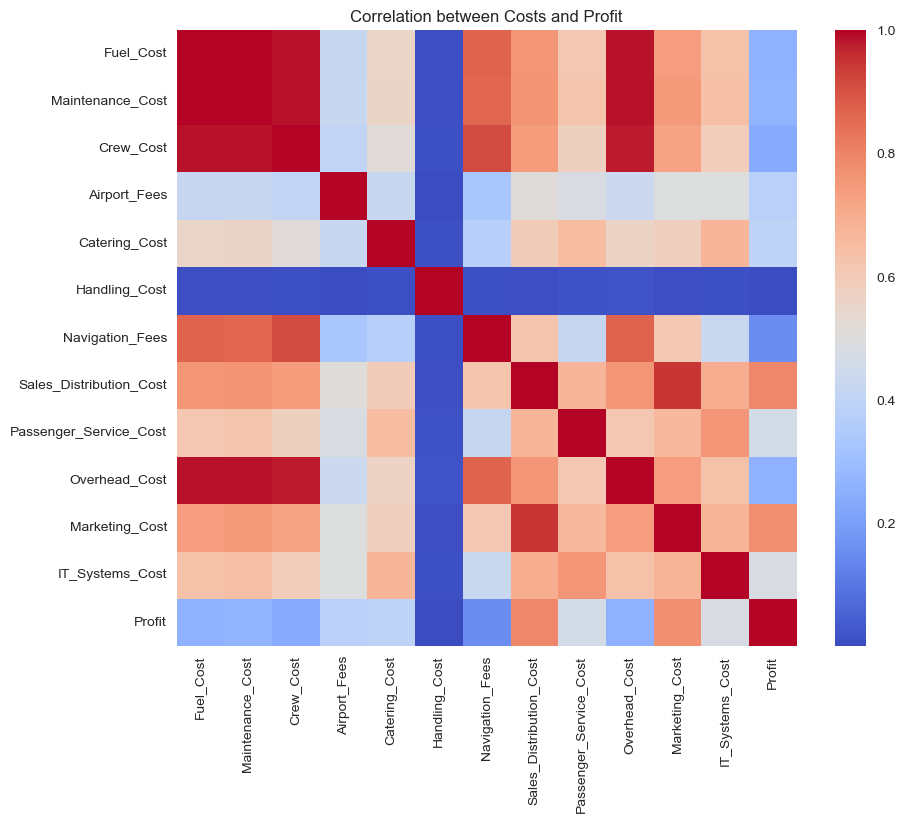

In [30]:
#Cost driver analysis
cost_columns = [
    "Fuel_Cost", "Maintenance_Cost", "Crew_Cost",
    "Airport_Fees", "Catering_Cost", "Handling_Cost",
    "Navigation_Fees", "Sales_Distribution_Cost",
    "Passenger_Service_Cost", "Overhead_Cost",
    "Marketing_Cost", "IT_Systems_Cost"
]

correlation = df[cost_columns + ["Profit"]].corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlation, cmap="coolwarm")
plt.title("Correlation between Costs and Profit")
plt.show()

In [31]:
# Key cost driver
profit_corr = correlation["Profit"].sort_values()

profit_corr

Handling_Cost              0.001520
Navigation_Fees            0.157234
Crew_Cost                  0.235895
Fuel_Cost                  0.257677
Overhead_Cost              0.260181
Maintenance_Cost           0.264020
Airport_Fees               0.382290
Catering_Cost              0.396927
Passenger_Service_Cost     0.461852
IT_Systems_Cost            0.485113
Marketing_Cost             0.775160
Sales_Distribution_Cost    0.790488
Profit                     1.000000
Name: Profit, dtype: float64

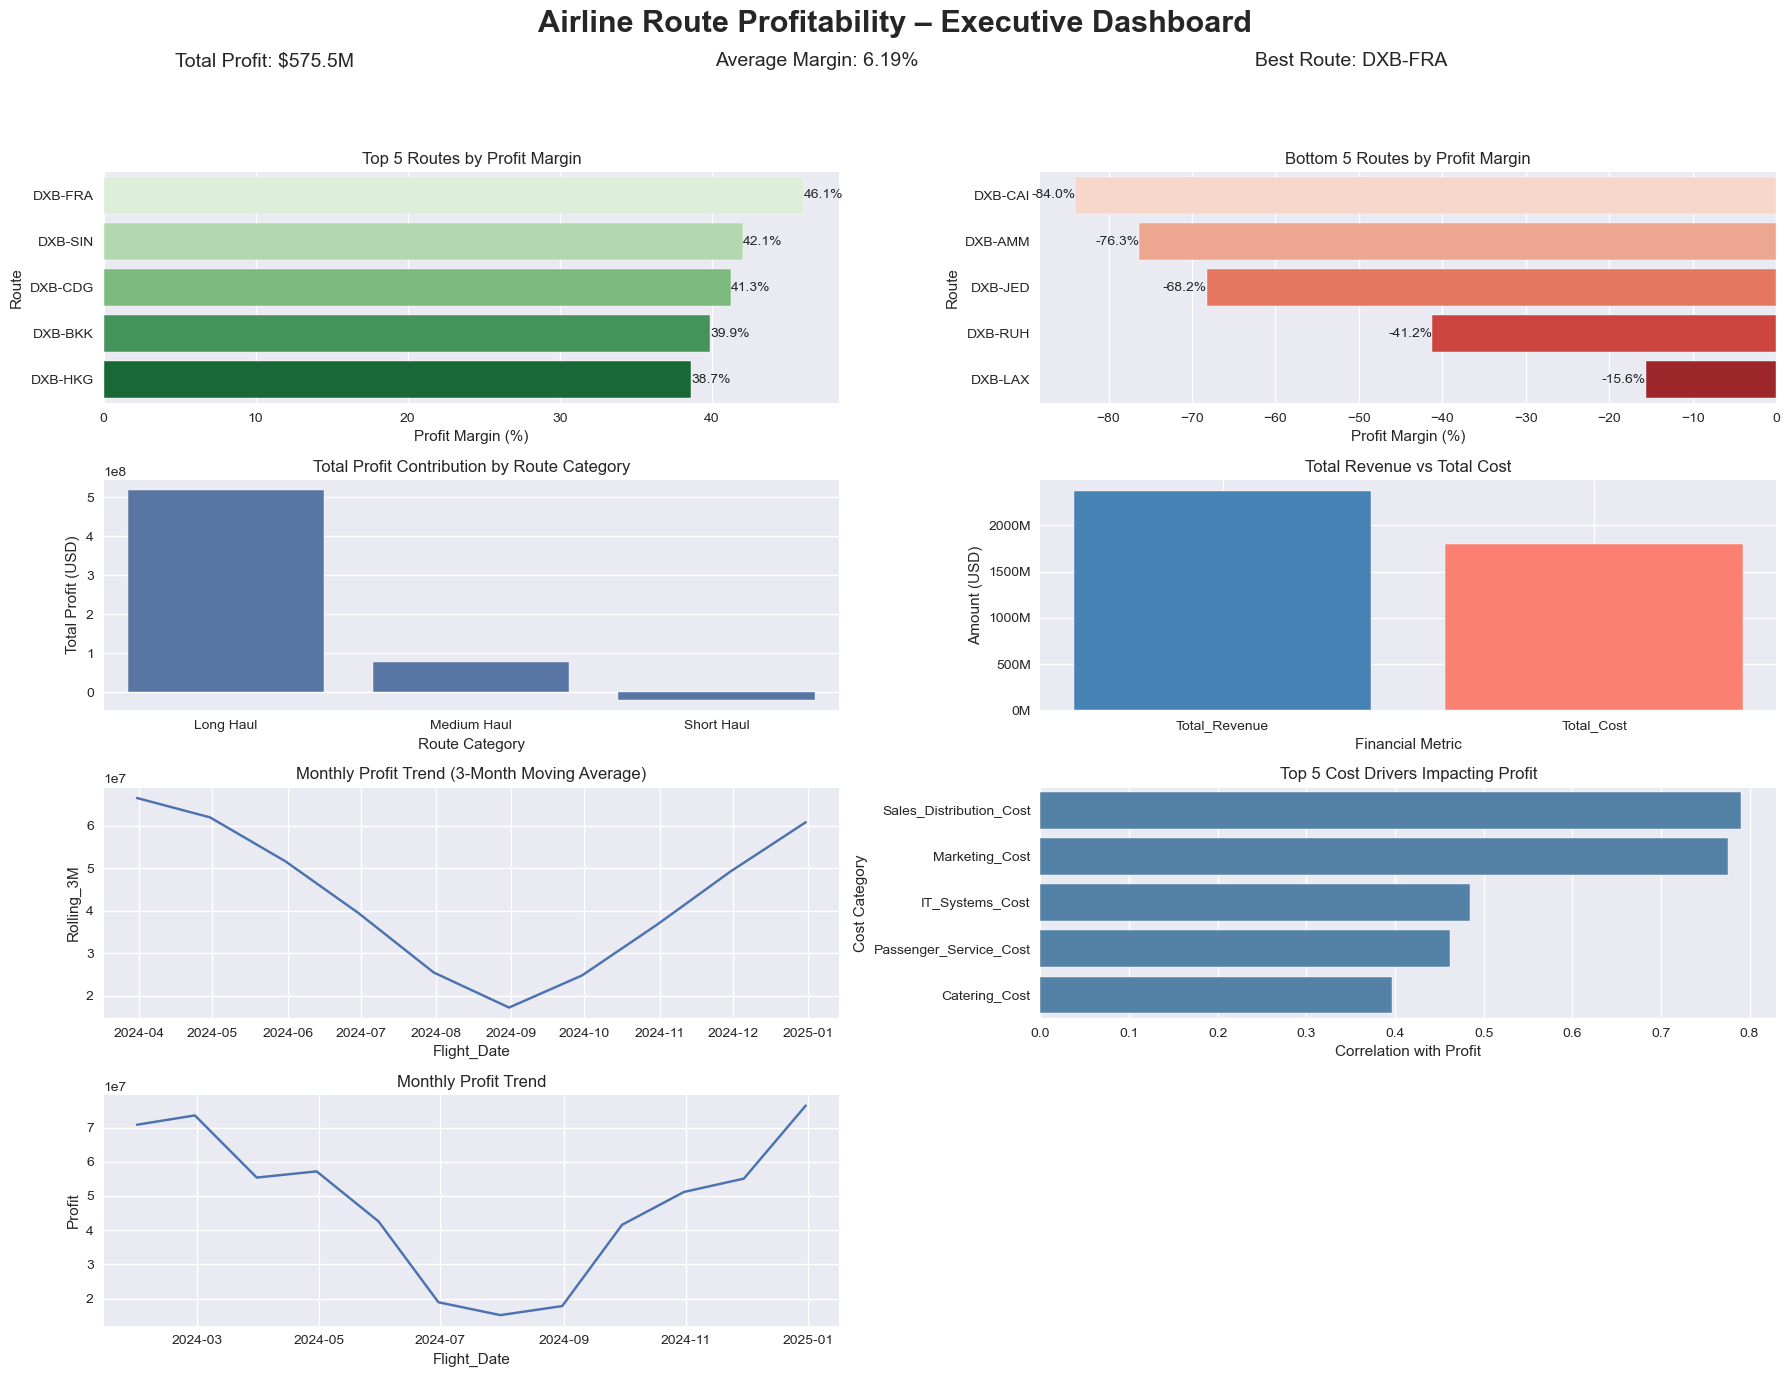

In [41]:
fig, axes = plt.subplots(4, 2, figsize=(18, 14))
fig.suptitle(
    "Airline Route Profitability – Executive Dashboard",
    fontsize=22,
    fontweight="bold"
)

total_profit = df["Profit"].sum()
avg_margin = df["Profit_Margin"].mean()
best_route = route_analysis.iloc[0]["Route"]

fig.text(0.1, 0.94, f"Total Profit: ${total_profit/1e6:.1f}M", fontsize=14)
fig.text(0.4, 0.94, f"Average Margin: {avg_margin:.2f}%", fontsize=14)
fig.text(0.7, 0.94, f"Best Route: {best_route}", fontsize=14)

# 1️. Top 5 Routes

top_5 = route_analysis.sort_values("Profit_Margin", ascending=False).head(5)

sns.barplot(
    data=top_5,
    x="Profit_Margin",
    y="Route",
    hue="Route",
    palette="Greens",
    legend=False,
    ax=axes[0, 0]
)
for container in axes[0,0].containers:
    axes[0,0].bar_label(container, fmt="%.1f%%")
    
axes[0, 0].set_title("Top 5 Routes by Profit Margin")
axes[0, 0].set_xlabel("Profit Margin (%)")
axes[0, 0].set_ylabel("Route")

# 2️. Bottom 5 Routes

bottom_5 = route_analysis.sort_values("Profit_Margin", ascending=True).head(5)

sns.barplot(
    data=bottom_5,
    x="Profit_Margin",
    y="Route",
    hue="Route",
    palette="Reds",
    legend=False,
    ax=axes[0, 1]
)
for container in axes[0,1].containers:
    axes[0,1].bar_label(container, fmt="%.1f%%")
    
axes[0, 1].set_title("Bottom 5 Routes by Profit Margin")
axes[0, 1].set_xlabel("Profit Margin (%)")
axes[0, 1].set_ylabel("Route")

# 3️. Profit Contribution by Route Category

category_profit_total = df.groupby("Route_Category")["Profit"].sum().reset_index()

sns.barplot(
    data=category_profit_total,
    x="Route_Category",
    y="Profit",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Total Profit Contribution by Route Category")
axes[1, 0].set_xlabel("Route Category")
axes[1, 0].set_ylabel("Total Profit (USD)")

# 4️. Revenue vs Cost

summary = df[["Total_Revenue", "Total_Cost"]].sum()

axes[1, 1].bar(summary.index, summary.values, color=["steelblue", "salmon"])
axes[1, 1].set_title("Total Revenue vs Total Cost")
axes[1,1].set_xlabel("Financial Metric")
axes[1,1].set_ylabel("Amount (USD)")
axes[1,1].yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M')
)

# 5️. Monthly Profit Trend

monthly_profit = (
    df.set_index("Flight_Date")
      .resample("ME")["Profit"]
      .sum()
      .reset_index()
)
monthly_profit["Rolling_3M"] = monthly_profit["Profit"].rolling(3).mean()

sns.lineplot(
    data=monthly_profit,
    x="Flight_Date",
   y="Rolling_3M",
    ax=axes[2, 0]
)
axes[2,0].set_title("Monthly Profit Trend (3-Month Moving Average)")


# 6️. Top 5 Cost Drivers

profit_corr = correlation["Profit"].drop("Profit").sort_values(ascending=False)
top_cost_drivers = profit_corr.head(5)

sns.barplot(
    x=top_cost_drivers.values,
    y=top_cost_drivers.index,
    ax=axes[2, 1],
    color="steelblue"
)
axes[2, 1].set_title("Top 5 Cost Drivers Impacting Profit")
axes[2,1].set_xlabel("Correlation with Profit")
axes[2,1].set_ylabel("Cost Category")


# 7️. Monthly Profit Trend

monthly_profit = (
    df.set_index("Flight_Date")
      .resample("ME")["Profit"]
      .sum()
      .reset_index()
)

sns.lineplot(
    data=monthly_profit,
    x="Flight_Date",
    y="Profit",
    ax=axes[3, 0]
)
axes[3, 0].set_title("Monthly Profit Trend")
fig.delaxes(axes[3,1])

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

Executive Summary

Project Overview

This analysis evaluated airline route profitability using operational, revenue, and cost data across 7,974 flights and 30 routes.

The objective was to identify:

- The most profitable routes
- Loss-generating routes
- The most efficient aircraft types
- Seasonal profitability patterns
- Key cost drivers impacting profit
    
Key Findings

1️. Route Profitability

- The most profitable route is DXB–FRA, with an average profit margin of approximately 46%.
- The worst performing route is DXB–CAI, with a margin of approximately –83%.
- Several short-haul routes show consistent negative margins.

This indicates structural inefficiencies in certain regional routes.

2️. Route Category Performance

- Long-haul routes generate the highest average margins (~22%).
- Medium-haul routes show moderate profitability (~13%).
- Short-haul routes are on average significantly unprofitable (~ –26%).

Strategic focus should shift toward long-haul operations.

3️. Aircraft Efficiency

- Most profitable aircraft:
   - Airbus A380
   - Boeing 777-300ER
- Least profitable aircraft:
   - Boeing 737-800
   - Airbus A320

High-capacity aircraft operating long-haul routes yield superior margins.

4️. Seasonal Impact

- Peak season shows the highest profitability (~17%).
- Low season is negative (~ –8%).

Revenue management strategies should adjust pricing and capacity seasonally.

5️. Cost Drivers

Correlation analysis shows that:

- Sales & Distribution Cost
- Marketing Cost
- Passenger Service Cost
- Fuel Cost

have the strongest impact on overall profitability.

Cost optimization in these areas offers the highest improvement potential.

Strategic Recommendations

1. Re-evaluate or restructure short-haul routes.
2. Allocate high-capacity aircraft to long-haul operations.
3. Implement seasonal pricing optimization.
4. Focus cost-control efforts on distribution, marketing, and fuel.

Business Impact

This analysis provides data-driven insights to support:

- Route optimization
- Fleet allocation decisions
- Cost reduction strategies
- Strategic revenue planning

The findings enable improved operational efficiency and margin expansion.